# Make duration, area, intensity plot, Figure 7

Files needed:

`mhwMetrics.nc`

Explore all metrics

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm

from cmap import Colormap
import seaborn as sns

In [2]:
path = "/pub/mariant3/WarmWaterMassesv1/"
metrics = xr.open_dataset(f"{path}data/mhwMetrics.nc")
# Only load the largest events
# metrics = metrics.where(metrics.event_area > 0.15e12, drop=True)

In [5]:
intensity = (metrics['volcello_weighted_thetao'] - 29).max(dim='time')
area = metrics['event_area'].max(dim='time')
thickness = metrics['event_thickness'].max(dim='time')
volume = metrics['event_volume'].max(dim='time')
duration = metrics['duration']

In [17]:
large_mhw = {
    252: '#038E62', 373: '#D34600', 559: '#6059A6', 723: '#E30E78',
    986: '#4F9704', 1071: '#E19D00', 1467: '#986204', 2096: '#F65D77',
    2253: '#C57E16', 2478: '#869415', 2883: '#16A34F', 3984: '#E10D10',
    4113: '#1B69AC', 4350: '#33A130', 5987: '#50B797', 6070: '#FC7B4C',
    7088: '#7A90C2', 7122: '#E377B8', 7196: '#97D13B'
}

paper_mhw = {
    373: '#D34600', 559: '#6059A6', 2478: '#869415',
    4113: '#1B69AC', 5987: '#50B797'
}

In [18]:
def plot_area_volume(metrics, intensity, area, thickness, volume,
                     custom_colors_all, custom_colors):

    df = pd.DataFrame({
        'mhw': metrics['mhw'].values,
        'duration': duration.values,
        'intensity': intensity.values,
        'event_area': area.values,
        'event_thickness': thickness.values,
        'event_volume': volume.values
    })

    df['mhw'] = df['mhw'].astype(int)
    default_color = '#BDBDBD'
    df['color'] = df['mhw'].apply(lambda x: custom_colors_all.get(x, default_color))

    max_area = df['event_area'].max()
    max_volume = df['event_volume'].max()


    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 13), sharex=True, sharey=True)

    ax1.scatter(
        df['duration'], df['intensity'],
        s=(df['event_area'] / max_area) * 3000,
        c=df['color'], alpha=0.7, edgecolor='k'
    )

    for _, row in df[df['mhw'].isin(custom_colors)].iterrows():
        text_x = row['duration'] - 15
        text_y = row['intensity'] - 0.3 if row['mhw'] in [559, 4113] else row['intensity'] + 0.3

        ax1.annotate(
            f'{row["mhw"]}',
            xy=(row['duration'], row['intensity']),
            xytext=(text_x, text_y),
            fontsize=25,
            color=custom_colors[row['mhw']],
            arrowprops=dict(arrowstyle='->', lw=1, color=custom_colors[row['mhw']]),
            ha='left', va='center'
        )

    ax1.set_ylabel('MHW Intensity [°C]', fontsize=25)
    ax1.set_ylim(0, 2)
    ax1.set_xlim(left=0)
    ax1.set_yticks(np.arange(0, 2.1, 0.25))
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}'))

    ax1.tick_params(axis='both', labelsize=25)

    legend_areas = np.percentile(df['event_area'], [90, 98.6, 99.3, 100])
    for a in legend_areas:
        ax1.scatter([], [],
                    s=(a / max_area) * 3000,
                    c='gray', alpha=0.5, edgecolor='k',
                    label=f'{a:.1e} m²')

    ax1.legend(
        title='Area [m²]',
        loc='upper left',
        bbox_to_anchor=(1, 1.05),
        frameon=False,
        fontsize=20,
        title_fontsize=25,
        labelspacing=2.7,
        borderpad=0.8,
        handletextpad=1.5
    )

    ax2.scatter(
        df['duration'], df['intensity'],
        s=(df['event_volume'] / max_volume) * 3000,
        c=df['color'], alpha=0.7, edgecolor='k'
    )

    for _, row in df[df['mhw'].isin(custom_colors)].iterrows():
        text_x = row['duration'] - 15
        text_y = row['intensity'] - 0.3 if row['mhw'] in [559, 4113] else row['intensity'] + 0.3

        ax2.annotate(
            f'{row["mhw"]}',
            xy=(row['duration'], row['intensity']),
            xytext=(text_x, text_y),
            fontsize=25,
            color=custom_colors[row['mhw']],
            arrowprops=dict(arrowstyle='->', lw=1, color=custom_colors[row['mhw']]),
            ha='left', va='center'
        )

    ax2.set_xlabel('MHW Duration [days]', fontsize=25)
    ax2.set_ylabel('MHW Intensity [°C]', fontsize=25)
    ax2.set_xlim(left=0)

    ax2.tick_params(axis='both', labelsize=25)

    legend_volumes = np.percentile(df['event_volume'], [90, 98.6, 99.3, 100])
    for v in legend_volumes:
        ax2.scatter([], [],
                    s=(v / max_volume) * 3000,
                    c='gray', alpha=0.5, edgecolor='k',
                    label=f'{v:.1e} m³')

    ax2.legend(
        title='Volume [m³]',
        loc='upper left',
        bbox_to_anchor=(1, 1.05),
        frameon=False,
        fontsize=20,
        title_fontsize=25,
        labelspacing=2.5,
        borderpad=0.8,
        handletextpad=1.5
    )

    plt.tight_layout()
    # plt.savefig("../figures/duration-vol-area-plot-16-1.png", dpi=400, bbox_inches="tight")
    plt.show()

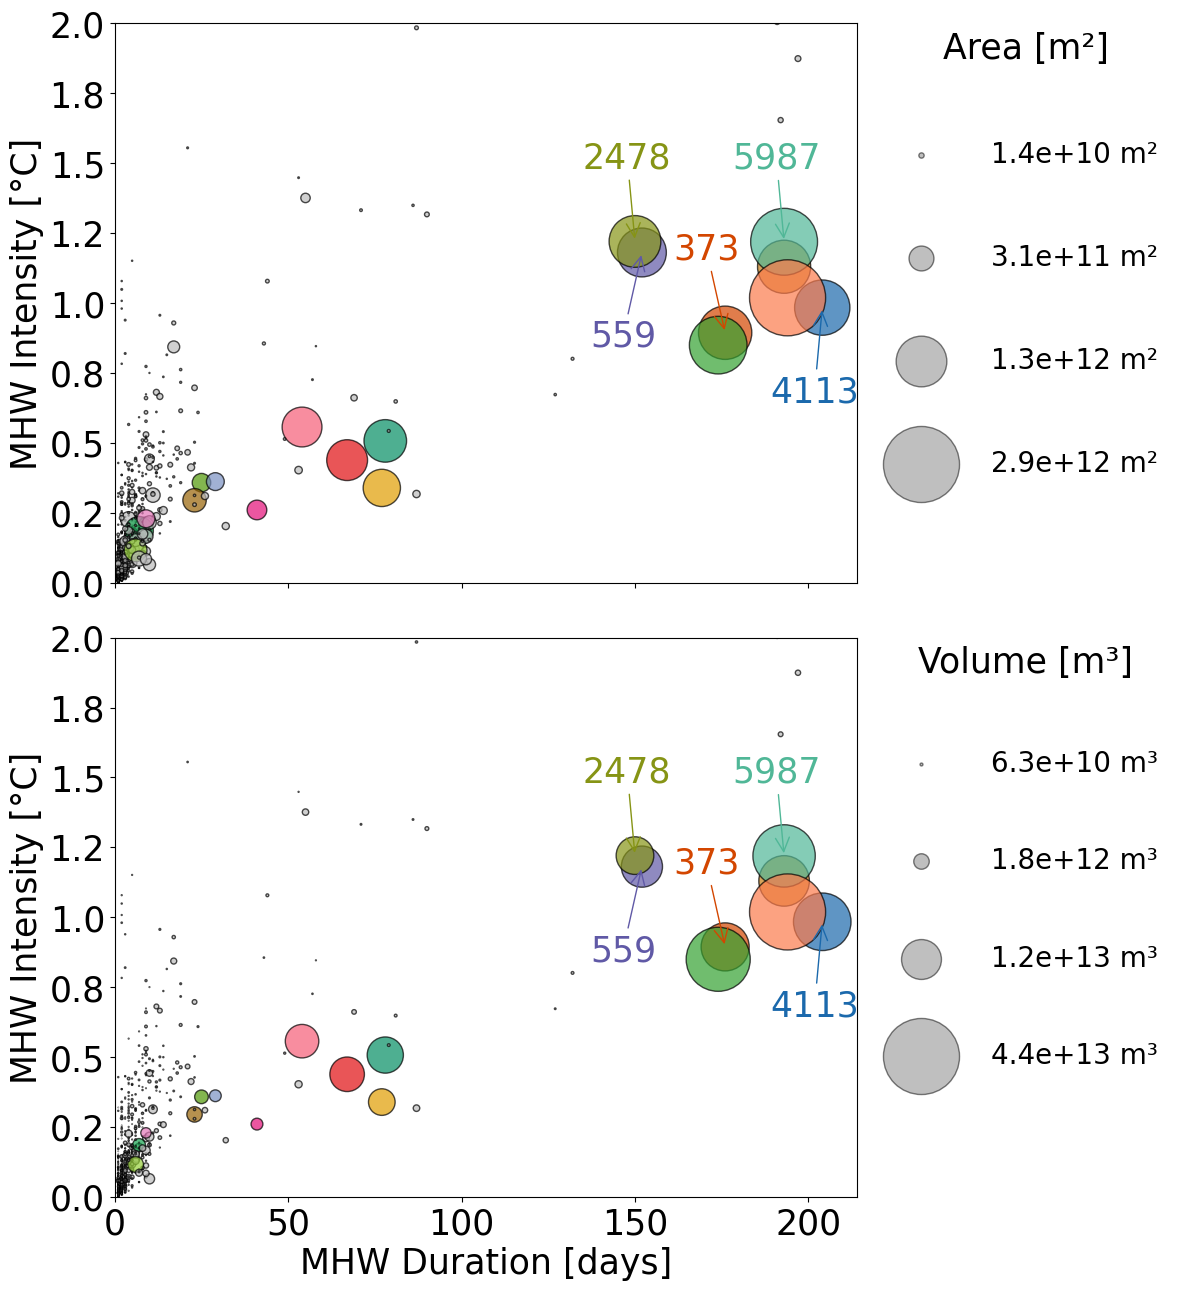

In [19]:
plot_area_volume(metrics, intensity, area, thickness, volume, large_mhw, paper_mhw)

n: [898.   1.   3.   1.   4.   2.   0.   1.   0.   1.]


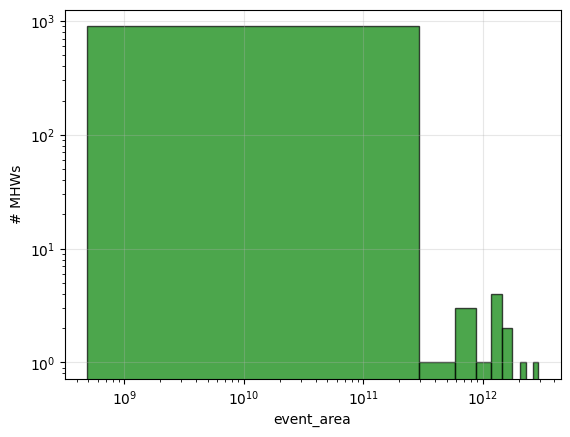

In [20]:
# big_events = metrics.event_area.where(metrics.event_area > 0.5e12, drop=True).mhw
var = 'event_area'
max_area = metrics[var].max(dim='time')

# plt.figure(figsize=(8, 6))
n, bins, patches = plt.hist(max_area, bins=10, color='green', alpha=0.7, edgecolor='black')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(f'{var}')
plt.ylabel('# MHWs')
plt.grid(True, alpha=0.3)

# n, bins, patches = plt.hist(max_area, bins=20, ...)
print("n:", n)
plt.show()